# Polynomial Regression: Salary Prediction

## Problem
In real life, salary does not grow in a perfectly straight line with experience. Raises are usually bigger early in a career and slow down later.

## Objective
Show that a **curve** fits this pattern better than a straight line, and learn how to choose the right polynomial degree without overfitting.

**Dataset:** `data/salary_data.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real people.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Load the Dataset

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("salary_data.csv"))
X = df[["years_experience"]]
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape:", df.shape, "| Training rows:", len(X_train), "| Test rows:", len(X_test))

Shape: (300, 4) | Training rows: 240 | Test rows: 60


## 3. What Is Polynomial Regression?

Polynomial regression is still **linear regression**, but we first add powers of the input as extra columns. With `degree=2`, the single column `x` becomes `[1, x, x²]`, so the model can draw a curve:

`salary = a + b·x + c·x²`

`PolynomialFeatures` creates these extra columns for us.

In [4]:
poly = PolynomialFeatures(degree=2)
demo = poly.fit_transform(pd.DataFrame({"years_experience": [1, 2, 3]}))
print("Columns are [1, x, x squared]:")
print(demo)

Columns are [1, x, x squared]:
[[1. 1. 1.]
 [1. 2. 4.]
 [1. 3. 9.]]


## 4. Train a Degree 2 Model and a Straight-Line Model

In [5]:
# Straight line (degree 1) for comparison
linear_model = LinearRegression().fit(X_train, y_train)

# Curve (degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_model = LinearRegression().fit(X_train_poly, y_train)

print("Models trained")

Models trained


## 5. Compare the Two Models on Test Data

In [6]:
lin_pred = linear_model.predict(X_test)
poly_pred = poly_model.predict(X_test_poly)

comparison = pd.DataFrame({
    "Model": ["Linear (degree 1)", "Polynomial (degree 2)"],
    "Test R2": [r2_score(y_test, lin_pred), r2_score(y_test, poly_pred)],
    "Test MAE (Rs.)": [mean_absolute_error(y_test, lin_pred), mean_absolute_error(y_test, poly_pred)],
    "Test RMSE (Rs.)": [np.sqrt(mean_squared_error(y_test, lin_pred)), np.sqrt(mean_squared_error(y_test, poly_pred))],
}).round(3)
comparison

,Model,Test R2,Test MAE (Rs.),Test RMSE (Rs.)
0,Linear (degree 1),0.853,49731.443,59475.787
1,Polynomial (degree 2),0.906,37635.040,47458.076


## 6. Visualize: Line vs Curve

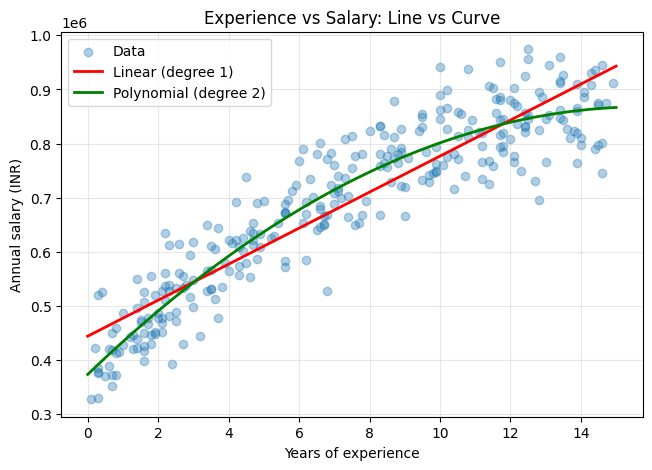

In [7]:
x_line = pd.DataFrame({"years_experience": np.linspace(0, 15, 150)})

plt.figure(figsize=(7.5, 5))
plt.scatter(X, y, alpha=0.35, label="Data")
plt.plot(x_line, linear_model.predict(x_line), color="red", linewidth=2, label="Linear (degree 1)")
plt.plot(x_line, poly_model.predict(poly.transform(x_line)), color="green", linewidth=2, label="Polynomial (degree 2)")
plt.title("Experience vs Salary: Line vs Curve")
plt.xlabel("Years of experience")
plt.ylabel("Annual salary (INR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The green curve bends and flattens at higher experience, matching the data. The red line keeps rising at a constant speed and overestimates the senior end.

## 7. Choosing the Degree (Avoiding Overfitting)

A higher degree always fits the **training** data a little better, but it can start to memorize noise. We test degrees 1 to 8 and compare **train** and **test** R².

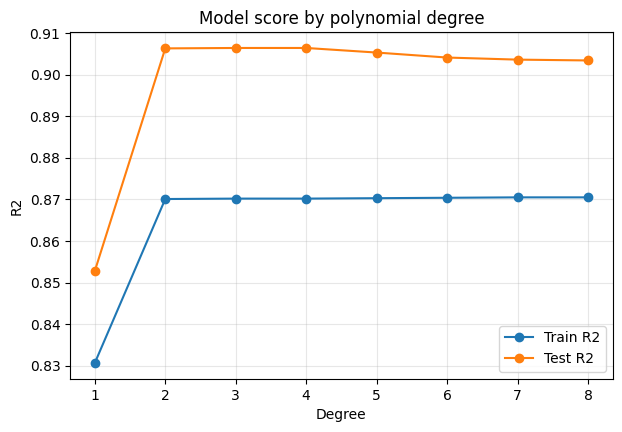

,Degree,Train R2,Test R2
0,1,0.8307,0.8528
1,2,0.8701,0.9063
2,3,0.8702,0.9064
3,4,0.8702,0.9064
4,5,0.8703,0.9053
5,6,0.8704,0.9041
6,7,0.8705,0.9036
7,8,0.8705,0.9034


In [8]:
rows = []
for degree in range(1, 9):
    pf = PolynomialFeatures(degree)
    tr, te = pf.fit_transform(X_train), pf.transform(X_test)
    m = LinearRegression().fit(tr, y_train)
    rows.append([degree, r2_score(y_train, m.predict(tr)), r2_score(y_test, m.predict(te))])

degrees = pd.DataFrame(rows, columns=["Degree", "Train R2", "Test R2"]).round(4)

plt.figure(figsize=(7, 4.5))
plt.plot(degrees["Degree"], degrees["Train R2"], marker="o", label="Train R2")
plt.plot(degrees["Degree"], degrees["Test R2"], marker="o", label="Test R2")
plt.title("Model score by polynomial degree")
plt.xlabel("Degree")
plt.ylabel("R2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

degrees

**How to read this:** the score jumps when we go from degree 1 to degree 2, then stays flat. Test R² even drops slightly after degree 4. Higher degrees add complexity without any benefit, so **degree 2** is the right choice: the simplest model that captures the curve.

## 8. Predict for New People

In [9]:
new_people = pd.DataFrame({"years_experience": [2, 6, 12]})
new_people["predicted_salary"] = poly_model.predict(poly.transform(new_people)).round(-2)
new_people

,years_experience,predicted_salary
0,2,490800.0
1,6,677800.0
2,12,839400.0


## Conclusion

- Salary growth slows down with experience, so a straight line is not the best fit.
- A degree 2 polynomial raises test **R² from 0.85 to 0.91** and lowers the average error from about Rs. 49,700 to **Rs. 37,600**.
- Going above degree 2 gives no extra benefit, so we keep the simplest model.
- Polynomial models behave badly outside the data range, so do not predict beyond 15 years of experience.
- The remaining error is due to other factors (education, skills), which the multiple regression notebook captures (R² 0.93).